# GuidaPlate — Next-Meal Risk State Prediction (Trend Experiment)
## Notebook 09

This notebook is a **separate experiment** from the whole-sequence LSTM (nb05) and HMM transition analysis (nb08).

**Task:** Given a prefix of real logged meals (nutrient vectors), predict the **next meal's** per-meal risk state (LOW / MODERATE / HIGH) using `meal_risk_state()` from nb08.

**Key design choices:**
- Empty (all-zero) slots are **excluded** — not treated as LOW
- Train/test split is **by patient** (same 80/20, `random_state=42` as nb05)
- Explicit **sequence-length** feature alongside zero-padded nutrient input
- Baselines evaluated **before** any neural model

**Not integrated into the backend** — evaluation-first only.

In [1]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Concatenate, Dense, Dropout, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

RANDOM_STATE = 42
TEST_SIZE = 0.2
RISK_CLASSES = ['LOW', 'MODERATE', 'HIGH']
RISK_ENCODE = {c: i for i, c in enumerate(RISK_CLASSES)}
N_STEPS = 6
N_FEATURES = 4

def project_root():
    p = Path('.').resolve()
    if p.name == 'notebooks':
        return p.parent
    if (p / 'models').exists():
        return p
    return p.parent

ROOT = project_root()
MODEL_DIR = ROOT / 'models'
STATS_DIR = ROOT / 'outputs' / 'stats'
FIG_DIR = ROOT / 'outputs' / 'figures'
STATS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {ROOT}')

Project root: /Users/jade/GUIDAPLATE


## Step 1 — Build training examples

Load `lstm_sequences_cache.npz` (same IFF-built arrays as nb05/nb08). Apply `meal_risk_state()` per slot.

For each valid prefix `0..t` → target `t+1`:
- All slots `0..t` and target `t+1` must be **non-empty** (not all-zero)
- Input nutrients are zero-padded to shape `(6, 4)`; `seq_length = t+1` is stored explicitly

In [2]:
# meal_risk_state — nb08 transition-matrix cell (G2 daily limits / 3)
THRESHOLDS = {
    'G2': {
        'potassium': 3500 / 3,
        'phosphorus': 1000 / 3,
        'protein': 0.8 / 3,
        'sodium': 2300 / 3,
    }
}
T = THRESHOLDS['G2']


def is_empty_slot(vec: np.ndarray) -> bool:
    return not np.any(vec != 0)


def meal_risk_state(meal_vec: np.ndarray) -> int:
    k, p, pr, s = meal_vec
    exceed = sum([
        k > T['potassium'],
        p > T['phosphorus'],
        pr > T['protein'],
        s > T['sodium'],
    ])
    if exceed >= 2:
        return 2
    if exceed == 1:
        return 1
    return 0


def build_examples(sequences: np.ndarray, patient_ids: np.ndarray):
    X_list, len_list, y_list, pid_list, last_state_list, prefix_t_list = [], [], [], [], [], []
    excluded_target = 0
    excluded_input = 0

    for i in range(len(sequences)):
        seq = sequences[i]
        states = [meal_risk_state(seq[j]) for j in range(N_STEPS)]

        for t in range(N_STEPS - 1):
            if is_empty_slot(seq[t + 1]):
                excluded_target += 1
                continue
            if any(is_empty_slot(seq[k]) for k in range(t + 1)):
                excluded_input += 1
                continue

            padded = np.zeros((N_STEPS, N_FEATURES), dtype=float)
            padded[: t + 1] = seq[: t + 1]
            X_list.append(padded)
            len_list.append(t + 1)
            y_list.append(states[t + 1])
            pid_list.append(patient_ids[i])
            last_state_list.append(states[t])
            prefix_t_list.append(t)

    return {
        'X': np.array(X_list),
        'seq_len': np.array(len_list, dtype=float),
        'y': np.array(y_list),
        'patient_ids': np.array(pid_list),
        'last_state': np.array(last_state_list),
        'prefix_t': np.array(prefix_t_list),
        'excluded_target': excluded_target,
        'excluded_input': excluded_input,
    }


cache = np.load(MODEL_DIR / 'lstm_sequences_cache.npz', allow_pickle=True)
sequences = cache['sequences']
full_labels = cache['labels']
patient_ids_seq = cache['patient_ids']

data = build_examples(sequences, patient_ids_seq)

print('=' * 55)
print('STEP 1 — TRAINING EXAMPLES')
print('=' * 55)
print(f'Patients in cache: {len(sequences)}')
print(f'Total examples generated: {len(data["y"]):,}')
print(f'Excluded (empty target slot): {data["excluded_target"]:,}')
print(f'Excluded (empty slot in prefix 0..t): {data["excluded_input"]:,}')
print()
print('Target label distribution (meal t+1):')
target_dist = pd.Series([RISK_CLASSES[y] for y in data['y']]).value_counts().reindex(RISK_CLASSES)
for cls in RISK_CLASSES:
    n = target_dist[cls]
    print(f'  {cls}: {n:,} ({n / len(data["y"]) * 100:.1f}%)')
print()
print('Examples by prefix length (real meals in input):')
print(pd.Series(data['seq_len']).value_counts().sort_index())

STEP 1 — TRAINING EXAMPLES
Patients in cache: 1830
Total examples generated: 6,181
Excluded (empty target slot): 1,783
Excluded (empty slot in prefix 0..t): 1,186

Target label distribution (meal t+1):
  LOW: 1,751 (28.3%)
  MODERATE: 824 (13.3%)
  HIGH: 3,606 (58.3%)

Examples by prefix length (real meals in input):
1.0    1424
2.0    1385
3.0    1168
4.0    1118
5.0    1086
Name: count, dtype: int64


## Step 2 — Patient-level train/test split

Split **patients** 80/20 (`random_state=42`), stratified by each patient's full-day label from the cache — consistent with nb05.

In [3]:
unique_pids = np.unique(patient_ids_seq)
pid_full_label = []
for pid in unique_pids:
    idx = np.where(patient_ids_seq == pid)[0][0]
    pid_full_label.append(RISK_ENCODE[full_labels[idx]])

train_pids, test_pids = train_test_split(
    unique_pids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=pid_full_label,
)
train_pid_set = set(train_pids)

train_mask = np.array([p in train_pid_set for p in data['patient_ids']])
test_mask = ~train_mask

X_all = data['X']
y_all = data['y']
seq_len_all = data['seq_len']
last_state_all = data['last_state']

X_train, X_test = X_all[train_mask], X_all[test_mask]
y_train, y_test = y_all[train_mask], y_all[test_mask]
seq_len_train, seq_len_test = seq_len_all[train_mask], seq_len_all[test_mask]
last_state_train, last_state_test = last_state_all[train_mask], last_state_all[test_mask]

print('=' * 55)
print('STEP 2 — PATIENT-LEVEL SPLIT')
print('=' * 55)
print(f'Train patients: {len(train_pids):,} | Test patients: {len(test_pids):,}')
print(f'Train examples: {len(y_train):,} | Test examples: {len(y_test):,}')

STEP 2 — PATIENT-LEVEL SPLIT
Train patients: 1,464 | Test patients: 366
Train examples: 4,985 | Test examples: 1,196


## Step 3 — Baselines (no training)

(a) Majority class — always predict the most common target class in training

(b) Repeat last meal — predict the same state as meal `t` (most recent real meal)

(c) Transition matrix — `models/transition_matrix.json` from nb08; predict argmax P(next | last state)

In [4]:
with open(MODEL_DIR / 'transition_matrix.json') as f:
    tm = json.load(f)

tm_idx = {
    0: np.array([tm['LOW']['LOW'], tm['LOW']['MODERATE'], tm['LOW']['HIGH']]),
    1: np.array([tm['MODERATE']['LOW'], tm['MODERATE']['MODERATE'], tm['MODERATE']['HIGH']]),
    2: np.array([tm['HIGH']['LOW'], tm['HIGH']['MODERATE'], tm['HIGH']['HIGH']]),
}


def evaluate_predictions(y_true, y_pred, y_proba=None, name='model'):
    acc = accuracy_score(y_true, y_pred)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_per = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    high_idx = RISK_ENCODE['HIGH']
    high_sens = ((y_true == high_idx) & (y_pred == high_idx)).sum() / max((y_true == high_idx).sum(), 1)
    row = {
        'model': name,
        'accuracy': round(acc, 4),
        'f1_weighted': round(f1_w, 4),
        'f1_LOW': round(float(f1_per[0]), 4),
        'f1_MODERATE': round(float(f1_per[1]), 4),
        'f1_HIGH': round(float(f1_per[2]), 4),
        'high_sensitivity': round(float(high_sens), 4),
    }
    if y_proba is not None:
        row['auc_roc'] = round(roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted'), 4)
    else:
        row['auc_roc'] = np.nan
    return row


majority_class = int(np.bincount(y_train, minlength=3).argmax())
pred_majority = np.full_like(y_test, majority_class)
pred_repeat = last_state_test.copy()
pred_trans = np.array([int(np.argmax(tm_idx[s])) for s in last_state_test])

results = [
    evaluate_predictions(y_test, pred_majority, name='majority_class'),
    evaluate_predictions(y_test, pred_repeat, name='repeat_last_meal'),
    evaluate_predictions(y_test, pred_trans, name='transition_matrix'),
]

print('=' * 55)
print('STEP 3 — BASELINES (test set)')
print('=' * 55)
print(f'Majority class in training targets: {RISK_CLASSES[majority_class]}')
print()
baseline_df = pd.DataFrame(results)
print(baseline_df.to_string(index=False))

STEP 3 — BASELINES (test set)
Majority class in training targets: HIGH

            model  accuracy  f1_weighted  f1_LOW  f1_MODERATE  f1_HIGH  high_sensitivity  auc_roc
   majority_class    0.5870       0.4342  0.0000       0.0000   0.7397            1.0000      NaN
 repeat_last_meal    0.4373       0.4476  0.3346       0.1509   0.5668            0.5285      NaN
transition_matrix    0.4900       0.4602  0.3346       0.0000   0.6210            0.6524      NaN


## Step 4 — Trained sequence model

**Architecture choice: GRU (32 units)** — not a stacked LSTM.

Rationale: ~5,000 training examples after patient split. A single GRU layer with explicit sequence-length concatenation is sufficient capacity without overfitting risk from a deeper LSTM stack. Inputs: scaled `(6, 4)` nutrient prefix + normalized `seq_length` scalar.

In [5]:
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, N_FEATURES))


def scale_batch(X, sc):
    n = X.shape[0]
    return sc.transform(X.reshape(-1, N_FEATURES)).reshape(n, N_STEPS, N_FEATURES)


X_train_s = scale_batch(X_train, scaler)
X_test_s = scale_batch(X_test, scaler)

seq_len_train_n = (seq_len_train - 1) / (N_STEPS - 1)
seq_len_test_n = (seq_len_test - 1) / (N_STEPS - 1)

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

tf.random.set_seed(RANDOM_STATE)

nut_in = Input(shape=(N_STEPS, N_FEATURES), name='nutrients')
len_in = Input(shape=(1,), name='seq_length')
h = GRU(32, dropout=0.2, name='gru')(nut_in)
h = Concatenate(name='concat_len')([h, len_in])
h = Dense(16, activation='relu')(h)
h = Dropout(0.2)(h)
out = Dense(3, activation='softmax', name='next_meal')(h)
model = Model(inputs=[nut_in, len_in], outputs=out, name='NextMealGRU')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

history = model.fit(
    [X_train_s, seq_len_train_n],
    y_train_cat,
    validation_split=0.15,
    epochs=50,
    batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)],
    verbose=1,
)

y_proba = model.predict([X_test_s, seq_len_test_n], verbose=0)
y_pred = np.argmax(y_proba, axis=1)

results.append(evaluate_predictions(y_test, y_pred, y_proba, name='trained_GRU'))

print('=' * 55)
print('TRAINED GRU — TEST METRICS')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=RISK_CLASSES, zero_division=0))

Model: "NextMealGRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nutrients           │ (None, 6, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      3,648 │ nutrients[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_length          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_len          │ (None, 33)        │          0 │ gru[0][0],        │
│ (Concatenate)       │                   │            │ seq_length[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        544 │ concat_len[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_meal (Dense)   │ (None, 3)         │         51 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,243 (16.57 KB)

 Trainable params: 4,243 (16.57 KB)

 Non-trainable params: 0 (0.00 B)

...

 1/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5469 - loss: 0.9815

58/67 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - accuracy: 0.6081 - loss: 0.8987

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6158 - loss: 0.8949 - val_accuracy: 0.6056 - val_loss: 0.9095


Restoring model weights from the end of the best epoch: 48.


TRAINED GRU — TEST METRICS
              precision    recall  f1-score   support

         LOW       0.52      0.22      0.31       342
    MODERATE       0.00      0.00      0.00       152
        HIGH       0.62      0.93      0.75       702

    accuracy                           0.61      1196
   macro avg       0.38      0.38      0.35      1196
weighted avg       0.52      0.61      0.53      1196



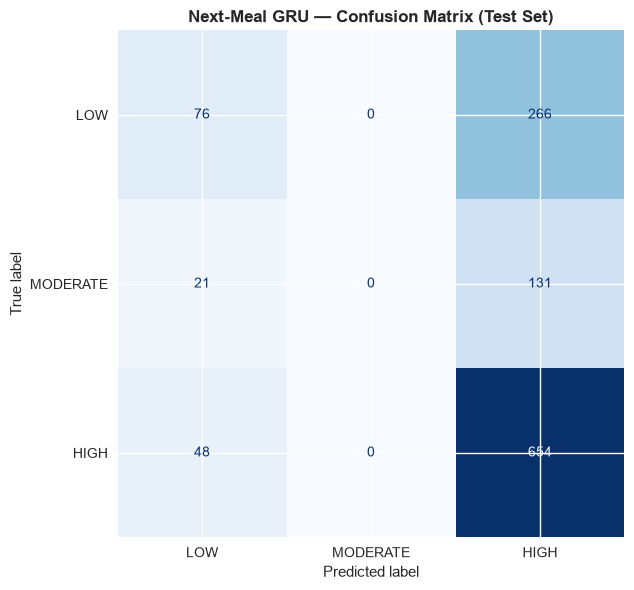

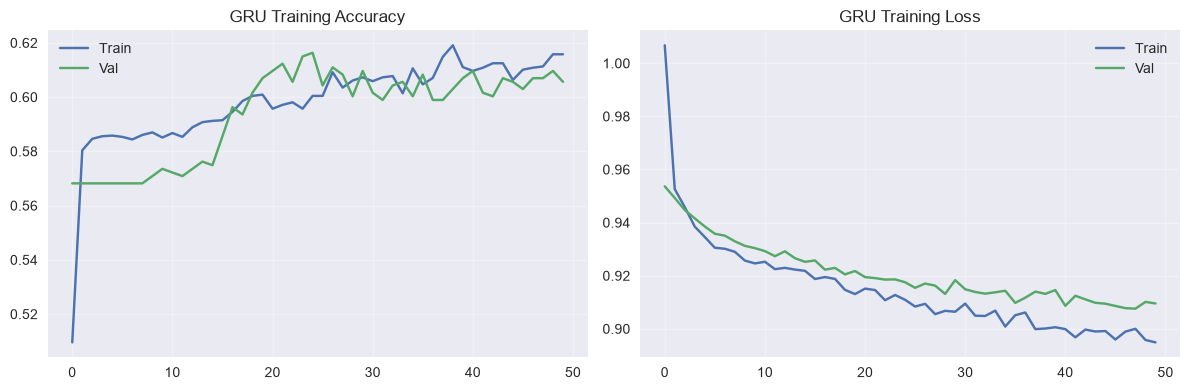

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_CLASSES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Next-Meal GRU — Confusion Matrix (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '26_trend_prediction_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('GRU Training Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('GRU Training Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '27_trend_prediction_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Comparison and interpretation

In [7]:
comparison_df = pd.DataFrame(results)
comparison_df.to_csv(STATS_DIR / '17_trend_prediction_comparison.csv', index=False)

print('=' * 70)
print('STEP 5 — FULL COMPARISON (test set)')
print('=' * 70)
print(comparison_df.to_string(index=False))
print()
print(f'Saved: {STATS_DIR / "17_trend_prediction_comparison.csv"}')
print(f'Saved: {FIG_DIR / "26_trend_prediction_confusion_matrix.png"}')
print(f'Saved: {FIG_DIR / "27_trend_prediction_training_history.png"}')
print()

gru_acc = comparison_df.loc[comparison_df['model'] == 'trained_GRU', 'accuracy'].iloc[0]
tm_acc = comparison_df.loc[comparison_df['model'] == 'transition_matrix', 'accuracy'].iloc[0]
maj_acc = comparison_df.loc[comparison_df['model'] == 'majority_class', 'accuracy'].iloc[0]
rep_acc = comparison_df.loc[comparison_df['model'] == 'repeat_last_meal', 'accuracy'].iloc[0]

print('INTERPRETATION')
print('-' * 70)
print(f'• Trained GRU accuracy: {gru_acc:.1%}')
print(f'• vs transition-matrix baseline: {tm_acc:.1%} (+{(gru_acc - tm_acc)*100:.1f} pp)')
print(f'• vs repeat-last-meal baseline: {rep_acc:.1%} (+{(gru_acc - rep_acc)*100:.1f} pp)')
print(f'• vs majority-class baseline: {maj_acc:.1%} (+{(gru_acc - maj_acc)*100:.1f} pp)')
print()
if gru_acc - tm_acc >= 0.05:
    print('The GRU meaningfully outperforms the zero-training transition-matrix baseline.')
    print('Nutrient-sequence context adds value beyond first-order Markov transitions.')
elif gru_acc - tm_acc >= 0.02:
    print('The GRU shows modest improvement over the transition-matrix baseline.')
    print('Additional sequence context helps somewhat but gains are limited.')
else:
    print('The GRU does NOT clearly outperform the transition-matrix baseline.')
    print('Next-meal risk may be well-approximated by first-order Markov transitions.')
print()
print('MODERATE class remains hard for all models (minority class, ~14% of targets).')
print('No backend integration — review these results before deployment decisions.')

STEP 5 — FULL COMPARISON (test set)
            model  accuracy  f1_weighted  f1_LOW  f1_MODERATE  f1_HIGH  high_sensitivity  auc_roc
   majority_class    0.5870       0.4342  0.0000       0.0000   0.7397            1.0000      NaN
 repeat_last_meal    0.4373       0.4476  0.3346       0.1509   0.5668            0.5285      NaN
transition_matrix    0.4900       0.4602  0.3346       0.0000   0.6210            0.6524      NaN
      trained_GRU    0.6104       0.5272  0.3121       0.0000   0.7461            0.9316   0.6599

Saved: /Users/jade/GUIDAPLATE/outputs/stats/17_trend_prediction_comparison.csv
Saved: /Users/jade/GUIDAPLATE/outputs/figures/26_trend_prediction_confusion_matrix.png
Saved: /Users/jade/GUIDAPLATE/outputs/figures/27_trend_prediction_training_history.png

INTERPRETATION
----------------------------------------------------------------------
• Trained GRU accuracy: 61.0%
• vs transition-matrix baseline: 49.0% (+12.0 pp)
• vs repeat-last-meal baseline: 43.7% (+17.3 pp)
• vs